# Análisis de Redes Científicas con Grafos
**Área:** Sistemas Distribuidos  
**Asignatura:** Estructuras de Datos  
**Integrantes:**
- Juan Ángel Canche Góngora
- Mauricio Antonio De Lázaro Lara
- Christopher May Paat

In [7]:
from google.colab import drive
import os

drive.mount('/content/gdrive')
os.chdir('/content/gdrive/MyDrive/Grafos')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## 1. Recolección de datos
Consulta la API de Semantic Scholar y guarda los papers en un archivo JSON local.  
**Nota:** El archivo ya existe, puede omitirse.

In [ ]:
import requests
import json
import time
import os

# URL base de la API de Semantic Scholar
API_URL = "https://api.semanticscholar.org/graph/v1/"

# Carpeta y archivo de salida donde se guardan los papers recolectados
DIR_DATOS = "datos"
OUTPUT_FILE = os.path.join(DIR_DATOS, "papers_sistemas_distribuidos.json")

# Lista de términos de búsqueda — se puede ampliar para cubrir más áreas
QUERIES = ["Sistemas distribuidos"]


def obtener_datos(query: str, limite: int = 100, offset: int = 0) -> dict:
    """
    Realiza una solicitud a la API de Semantic Scholar y retorna los resultados.
    Si la API responde con código 429, espera 45 segundos y reintenta.
    """
    url = f"{API_URL}paper/search"
    params = {
        "query": query,
        "fields": "paperId,title,authors,year",
        "limit": limite,
        "offset": offset,
    }
    try:
        response = requests.get(url, params=params)
        if response.status_code == 200:
            return response.json()
        elif response.status_code == 429:
            # La API limita la cantidad de solicitudes por minuto
            print("Límite alcanzado. Esperando para reintentar...")
            time.sleep(45)
            return obtener_datos(query, limite, offset)
        else:
            print(f"Error en la solicitud: {response.status_code} - {response.text}")
            return {}
    except requests.exceptions.RequestException as e:
        print(f"Error en la solicitud: {e}")
        return {}


def procesar_datos() -> list:
    """
    Ejecuta todas las queries, filtra los papers válidos y guarda el resultado en JSON.
    Un paper es válido si tiene: paperId, año de publicación y al menos un autor con ID.
    """
    os.makedirs(DIR_DATOS, exist_ok=True)

    # Usa un diccionario indexado por paperId para evitar duplicados entre queries
    all_papers = {}

    for query in QUERIES:
        print(f"Obteniendo datos para la query: '{query}'")
        offset = 0

        while len(all_papers) < 100:
            resultados = obtener_datos(query, limite=100, offset=offset)

            if not resultados or "data" not in resultados:
                print("  -> Sin resultados.")
                break

            nuevos = 0
            for paper in resultados["data"]:
                pid = paper.get("paperId")
                authors = paper.get("authors", [])
                year = paper.get("year")

                # Filtra autores sin ID para garantizar nodos identificables en el grafo
                autores_validos = [a for a in authors if a.get("authorId")]

                if pid and pid not in all_papers and len(autores_validos) >= 1 and year:
                    all_papers[pid] = {
                        "paperId": pid,
                        "title": paper.get("title", "Sin título"),
                        "authors": [
                            {"authorId": a["authorId"], "name": a.get("name", "Desconocido")}
                            for a in autores_validos
                        ],
                        "year": year,
                    }
                    nuevos += 1

            print(f"  -> {nuevos} papers nuevos. Total acumulado: {len(all_papers)}")

            # Pausa para respetar el rate limit de la API
            time.sleep(1.5)
            offset += len(resultados["data"])

            if not resultados["data"] or len(all_papers) >= 100:
                break

    papers_lista = list(all_papers.values())

    # Verifica que se hayan recolectado al menos 100 autores únicos
    author_ids = {
        a["authorId"]
        for paper in papers_lista
        for a in paper["authors"]
        if a.get("authorId")
    }

    print(f"Autores únicos encontrados: {len(author_ids)}")
    if len(author_ids) >= 100:
        print("Se han agregado al menos 100 autores únicos.")
    else:
        print("Aún no se han agregado 100 autores únicos.")

    # Serializa los papers en formato JSON con indentación legible
    with open(OUTPUT_FILE, "w", encoding="utf-8") as archivo:
        json.dump(papers_lista, archivo, ensure_ascii=False, indent=2)

    return papers_lista


papers = procesar_datos()

## 2. Construcción del grafo
Construye el grafo de coautoría a partir de los datos recolectados y lo serializa en formato GraphML.

In [21]:
import json
import os
import networkx as nx
from itertools import combinations

# Rutas de entrada y salida
ARCHIVO_DATOS = os.path.join("datos", "papers_sistemas_distribuidos.json")
ARCHIVO_GRAFO = os.path.join("datos", "grafo_coautoria_sistemas_distribuidos.graphml")


def cargar_papers(ruta: str) -> list:
    """Lee el archivo JSON y retorna la lista de papers."""
    with open(ruta, "r", encoding="utf-8") as f:
        return json.load(f)


def construir_grafo(papers: list) -> nx.Graph:
    """
    Construye el grafo de coautoría a partir de la lista de papers.
    Por cada paper agrega nodos por autor y aristas por cada par de coautores.
    Si la arista ya existe, incrementa su peso en 1.
    """
    G = nx.Graph()

    for paper in papers:
        # Soporta tanto la clave "authors" como "autores" según el origen del JSON
        autores = paper.get("authors", paper.get("autores", []))

        # Filtra autores sin ID para evitar nodos sin identificador único
        autores_ids = [a["authorId"] for a in autores if a.get("authorId")]

        # Agrega un nodo por cada autor con su nombre como atributo
        for autor in autores:
            if autor.get("authorId"):
                G.add_node(autor["authorId"], name=autor.get("name", "Desconocido"))

        # Genera todos los pares posibles de autores del paper
        # Si ya existe la arista entre dos autores, incrementa el peso; si no, la crea con peso 1
        for a1, a2 in combinations(autores_ids, 2):
            if G.has_edge(a1, a2):
                G[a1][a2]["weight"] += 1
            else:
                G.add_edge(a1, a2, weight=1)

    return G


# Carga los papers, construye el grafo y lo serializa en formato GraphML
os.makedirs("datos", exist_ok=True)
papers_cargados = cargar_papers(ARCHIVO_DATOS)
G = construir_grafo(papers_cargados)
nx.write_graphml(G, ARCHIVO_GRAFO)
print(f"Grafo guardado en '{ARCHIVO_GRAFO}': {G.number_of_nodes()} nodos | {G.number_of_edges()} aristas")

Grafo guardado en 'datos/grafo_coautoria_sistemas_distribuidos.graphml': 243 nodos | 491 aristas


## 3. Análisis de la red
Ejecuta los cuatro análisis sobre el grafo:
- a) Caminos mínimos (Dijkstra)
- b) Centralidad (Degree, Betweenness, Closeness)
- c) Componentes conexas
- d) Detección de comunidades

In [22]:
import os
import networkx as nx
from networkx.algorithms import community as nx_community

# Ruta del grafo generado en la sección anterior
ARCHIVO_GRAFO = os.path.join("datos", "grafo_coautoria_sistemas_distribuidos.graphml")


def load_graph(path):
    """Carga el grafo desde un archivo GraphML y normaliza los pesos de las aristas a float."""
    G = nx.read_graphml(path)
    # Convierte el peso de cada arista a float para garantizar operaciones numéricas correctas
    for node_a, node_b, edge_data in G.edges(data=True):
        try:
            edge_data['weight'] = float(edge_data.get('weight', 1.0))
        except Exception:
            edge_data['weight'] = 1.0
    return G


def analizar_caminos(G, top_k_pairs=3):
    """
    Calcula los caminos mínimos entre los pares de autores con más colaboraciones.
    Usa Dijkstra sobre el peso inverso (1/weight) para que mayor colaboración
    signifique menor distancia.
    """
    print(f"\n{'='*55}")
    print("  a) CAMINOS MINIMOS")
    print(f"{'='*55}")

    # Selecciona los pares de autores con mayor número de colaboraciones
    edges = sorted(G.edges(data=True), key=lambda e: float(e[2].get("weight", 0)), reverse=True)[:top_k_pairs]
    if not edges:
        print("  No hay aristas en el grafo.")
        return []

    resultados = []

    # Agrega el atributo inv_weight a cada arista: mayor peso = menor distancia
    for author_a, author_b, edge_data in G.edges(data=True):
        weight_value = float(edge_data.get("weight", 1))
        edge_data["inv_weight"] = 1.0 / weight_value if weight_value != 0 else float('inf')

    for idx, (author_a, author_b, edge_info) in enumerate(edges, start=1):
        name_a = G.nodes[author_a].get("name", author_a)
        name_b = G.nodes[author_b].get("name", author_b)
        print(f"\n  Pareja {idx}: {name_a} <-> {name_b}, colaboraciones={int(edge_info.get('weight',0))}")

        if not nx.has_path(G, author_a, author_b):
            print("    No hay camino entre los autores seleccionados.")
            resultados.append({"pareja": (author_a, author_b), "dijkstra": None})
            continue

        # Aplica Dijkstra usando inv_weight para encontrar el camino más fuerte
        path_d = nx.dijkstra_path(G, author_a, author_b, weight="inv_weight")
        dist_d = nx.dijkstra_path_length(G, author_a, author_b, weight="inv_weight")
        print(f"    [Dijkstra] Distancia ponderada: {dist_d:.4f} | Saltos: {len(path_d)-1}")
        print("    Ruta:")
        for node_id in path_d:
            print(f"      -> {G.nodes[node_id].get('name', node_id)}")
        resultados.append({"pareja": (author_a, author_b), "dijkstra": {"ruta": path_d, "valor": dist_d}})

    # Elimina el atributo temporal inv_weight para no alterar el grafo original
    for _, _, edge_data in G.edges(data=True):
        if "inv_weight" in edge_data:
            del edge_data["inv_weight"]

    return resultados


def analizar_centralidad(G):
    """
    Calcula Degree, Betweenness y Closeness Centrality.
    Betweenness y Closeness usan inv_weight para que mayor colaboración = menor distancia.
    """
    print(f"\n{'='*55}")
    print("  b) CENTRALIDAD")
    print(f"{'='*55}")

    # Degree Centrality no usa pesos — solo cuenta conexiones directas
    degree_cent = nx.degree_centrality(G)

    # Agrega inv_weight para que Betweenness y Closeness reflejen la fuerza de colaboración
    for node_a, node_b, edge_data in G.edges(data=True):
        try:
            w = float(edge_data.get('weight', 1.0))
        except Exception:
            w = 1.0
        edge_data['inv_weight'] = 1.0 / w if w > 0 else float('inf')

    peso = 'inv_weight'
    betweenness_cent = nx.betweenness_centrality(G, weight=peso)
    closeness_cent = nx.closeness_centrality(G, distance=peso)

    # Elimina el atributo temporal para no alterar el grafo original
    for _, _, edge_data in G.edges(data=True):
        if 'inv_weight' in edge_data:
            del edge_data['inv_weight']

    def top5(metrica, label):
        # Muestra los 5 nodos con mayor valor en la métrica dada
        ranking = sorted(metrica.items(), key=lambda item: item[1], reverse=True)[:5]
        print(f"\n  Top 5 - {label}:")
        for idx, (node_id, val) in enumerate(ranking, 1):
            name = G.nodes[node_id].get("name", node_id)
            print(f"    {idx}. {name} ({val:.4f})")

    top5(degree_cent, "Degree Centrality")
    top5(betweenness_cent, "Betweenness Centrality")
    top5(closeness_cent, "Closeness Centrality")

    return {"degree": degree_cent, "betweenness": betweenness_cent, "closeness": closeness_cent}


def analizar_componentes(G):
    """
    Analiza las componentes conexas del grafo.
    Una componente conexa es un subconjunto de nodos donde todos están
    conectados entre sí, pero no tienen conexión con el resto del grafo.
    """
    print(f"\n{'='*55}")
    print("  c) COMPONENTES CONEXAS")
    print(f"{'='*55}")

    # Ordena las componentes de mayor a menor para identificar fácilmente la gigante
    components = sorted(nx.connected_components(G), key=len, reverse=True)

    # Nodos aislados: autores sin ninguna colaboración registrada
    aislados = [node_id for node_id, deg in G.degree() if deg == 0]

    print(f"\n  Total de componentes  : {len(components)}")
    print(f"  Autores aislados      : {len(aislados)}")
    if components:
        print(f"  Componente gigante    : {len(components[0])} nodos")
    print(f"\n  Tamano de las 10 componentes mas grandes:")
    for idx, comp in enumerate(components[:10], 1):
        print(f"    {idx}. {len(comp)} nodos")
    if components:
        print(f"\n  Autores en la componente gigante (muestra de 5):")
        for node_id in list(components[0])[:5]:
            print(f"    - {G.nodes[node_id].get('name', node_id)}")

    return {"components": components, "isolates": aislados}


def analizar_comunidades(G):
    """
    Detecta comunidades usando el algoritmo de modularidad greedy.
    La modularidad mide qué tan bien separadas están las comunidades.
    """
    print(f"\n{'='*55}")
    print("  d) DETECCION DE COMUNIDADES")
    print(f"{'='*55}")

    # Detecta comunidades maximizando la modularidad del grafo
    comms = list(nx_community.greedy_modularity_communities(G, weight="weight"))

    # Construye el mapa nodo -> índice de comunidad
    mapa = {}
    for idx, community in enumerate(comms):
        for node_id in community:
            mapa[node_id] = idx

    mod = nx_community.modularity(G, comms, weight="weight")
    print(f"\n  Comunidades detectadas: {len(comms)}")
    print(f"  Modularidad: {mod:.4f}")

    # Muestra una muestra de las 5 comunidades más grandes
    for idx, community in enumerate(sorted(comms, key=len, reverse=True)[:5], 1):
        nombres = [G.nodes[node_id].get('name', node_id) for node_id in list(community)[:3]]
        print(f"    Comunidad {idx} - {len(community)} autores | Ej: {', '.join(nombres)}...")

    return mapa


# Carga el grafo para el análisis
G = load_graph(ARCHIVO_GRAFO)
print(f"Grafo cargado: {G.number_of_nodes()} nodos | {G.number_of_edges()} aristas")

Grafo cargado: 243 nodos | 491 aristas


### a) Caminos mínimos

In [9]:
caminos = analizar_caminos(G, top_k_pairs=3)


  a) CAMINOS MINIMOS

  Pareja 1: P. Pesado <-> R. Bertone, colaboraciones=3
    [Dijkstra] Distancia ponderada: 0.3333 | Saltos: 1
    Ruta:
      -> P. Pesado
      -> R. Bertone

  Pareja 2: P. Pesado <-> Pablo J. Thomas, colaboraciones=3
    [Dijkstra] Distancia ponderada: 0.3333 | Saltos: 1
    Ruta:
      -> P. Pesado
      -> Pablo J. Thomas

  Pareja 3: R. Bertone <-> Pablo J. Thomas, colaboraciones=3
    [Dijkstra] Distancia ponderada: 0.3333 | Saltos: 1
    Ruta:
      -> R. Bertone
      -> Pablo J. Thomas


### b) Centralidad

In [10]:
centralidad = analizar_centralidad(G)


  b) CENTRALIDAD

  Top 5 - Degree Centrality:
    1. P. Pesado (0.0826)
    2. R. Bertone (0.0826)
    3. Pablo J. Thomas (0.0826)
    4. L. Marrero (0.0826)
    5. Lisandro Nahuel Delía (0.0826)

  Top 5 - Betweenness Centrality:
    1. Ekain Azketa (0.0006)
    2. J. Javier Gutiérrez (0.0005)
    3. P. Pesado (0.0004)
    4. R. Bertone (0.0004)
    5. Pablo J. Thomas (0.0004)

  Top 5 - Closeness Centrality:
    1. P. Pesado (0.1167)
    2. R. Bertone (0.1167)
    3. Pablo J. Thomas (0.1167)
    4. L. Marrero (0.1033)
    5. Lisandro Nahuel Delía (0.1033)


### c) Componentes conexas

In [11]:
comp_info = analizar_componentes(G)


  c) COMPONENTES CONEXAS

  Total de componentes  : 84
  Autores aislados      : 31
  Componente gigante    : 21 nodos

  Tamano de las 10 componentes mas grandes:
    1. 21 nodos
    2. 11 nodos
    3. 10 nodos
    4. 7 nodos
    5. 7 nodos
    6. 7 nodos
    7. 7 nodos
    8. 6 nodos
    9. 6 nodos
    10. 5 nodos

  Autores en la componente gigante (muestra de 5):
    - Lisandro Nahuel Delía
    - Rocío Muñoz
    - M. Boracchia
    - H. Ramón
    - Ariel C. Pasini


### d) Detección de comunidades

In [12]:
mapa_comunidad = analizar_comunidades(G)


  d) DETECCION DE COMUNIDADES

  Comunidades detectadas: 84
  Modularidad: 0.7969
    Comunidad 1 - 21 autores | Ej: P. Pesado, Martín Puig, Lisandro Nahuel Delía...
    Comunidad 2 - 11 autores | Ej: V. Puente, S. Pickin, Á. Pérez...
    Comunidad 3 - 10 autores | Ej: M. Aldea, Andoni Amurrio, Héctor Pérez Tijero...
    Comunidad 4 - 7 autores | Ej: D. L. R. Martínez, Jorge Tomás Fornerón Martínez, J. Acosta...
    Comunidad 5 - 7 autores | Ej: Rafael de la Rosa Flores, Daniel Sánchez Ruiz, Misael Limón Martínez...


## 4. Visualización
Genera dos visualizaciones y las guarda en la carpeta `visualizaciones/`:
- **grafo_completo.png** — todos los nodos coloreados por comunidad (top 5)
- **nodos_importantes.png** — top 15 autores más influyentes en base a Degree Centrality

In [14]:
import os
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Carpeta donde se guardan las imágenes generadas
DIR_SALIDA = "visualizaciones"


def grafo_componente_gigante(G):
    """Retorna el subgrafo formado únicamente por los nodos de la componente conexa más grande."""
    componente = max(nx.connected_components(G), key=len)
    return G.subgraph(componente).copy()


def visualizar_grafo_completo(G, mapa_comunidad):
    """
    Genera una imagen del grafo completo coloreando los nodos según su comunidad.
    Solo se destacan con color las 5 comunidades más grandes; el resto aparece en gris.
    """
    print("Generando grafo completo...")

    # Cuenta cuántos nodos tiene cada comunidad y selecciona las 5 más grandes
    tam_comunidades = Counter(mapa_comunidad.values())
    top5_indices = {idx for idx, _ in tam_comunidades.most_common(5)}

    # Asigna un color distinto a cada una de las 5 comunidades
    _paleta = [plt.colormaps.get_cmap("tab10")(i) for i in range(5)]
    _paleta[3] = (1.0, 1.0, 0.0, 1.0)
    top5_color = {idx: _paleta[i] for i, idx in enumerate(sorted(top5_indices, key=tam_comunidades.get, reverse=True))}

    # Nodos sin ninguna arista (sin colaboraciones)
    aislados = {n for n, deg in G.degree() if deg == 0}

    # Determina el color de cada nodo según su categoría
    colores = []
    for node in G.nodes():
        comm = mapa_comunidad.get(node)
        if comm in top5_color:
            colores.append(top5_color[comm])         # pertenece a una de las top 5 comunidades
        elif node in aislados:
            colores.append((0.4, 0.4, 0.4, 1.0))     # autor sin colaboraciones
        else:
            colores.append((0.25, 0.25, 0.35, 1.0))  # comunidad pequeña (fuera del top 5)

    # Calcula la posición de cada nodo simulando fuerzas físicas
    pos = nx.spring_layout(G, seed=42, k=0.6)

    fig, ax = plt.subplots(figsize=(18, 14))
    fig.patch.set_facecolor("#0f0f0f")
    ax.set_facecolor("#0f0f0f")

    # Calcula la transparencia de cada arista proporcional a su peso
    # Más colaboraciones = línea más visible
    pesos = [G[u][v]["weight"] for u, v in G.edges()]
    max_peso = max(pesos) if pesos else 1
    alphas = [0.05 + 0.95 * (w / max_peso) for w in pesos]

    # Dibuja cada arista como una línea entre las coordenadas de sus dos nodos
    for (u, v), alpha in zip(G.edges(), alphas):
        ax.plot(
            [pos[u][0], pos[v][0]],
            [pos[u][1], pos[v][1]],
            color="white", alpha=alpha, linewidth=0.5, zorder=1,
        )

    # Dibuja todos los nodos con sus colores asignados
    xs = [pos[n][0] for n in G.nodes()]
    ys = [pos[n][1] for n in G.nodes()]
    ax.scatter(xs, ys, c=colores, s=60, zorder=2, edgecolors="white", linewidths=0.3)

    # Construye la leyenda con las 5 comunidades más grandes y otras categorías
    top_comms = sorted(top5_color, key=tam_comunidades.get, reverse=True)
    parches = [
        mpatches.Patch(color=top5_color[idx], label=f"Comunidad {rank} ({tam_comunidades[idx]} autores)")
        for rank, idx in enumerate(top_comms, start=1)
    ]
    parches.append(mpatches.Patch(color=(0.25, 0.25, 0.35, 1.0), label="Otras comunidades"))
    parches.append(mpatches.Patch(color=(0.4, 0.4, 0.4, 1.0), label="Autores aislados"))
    ax.legend(handles=parches, loc="lower left", fontsize=8,
              facecolor="#1a1a1a", edgecolor="white", labelcolor="white")

    ax.set_title(
        f"Grafo completo\n"
        f"{G.number_of_nodes()} autores | {G.number_of_edges()} colaboraciones | {len(tam_comunidades)} comunidades",
        color="white", fontsize=13, pad=15,
    )
    ax.axis("off")

    os.makedirs(DIR_SALIDA, exist_ok=True)
    ruta = os.path.join(DIR_SALIDA, "grafo_completo.png")
    plt.savefig(ruta, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close()
    print(f"  Guardado en: {ruta}")


def visualizar_nodos_importantes(G, centralidad, top_n=15):
    """
    Genera una imagen destacando los top_n autores más influyentes según Degree Centrality.
    Se trabaja sobre la componente gigante para excluir nodos aislados del análisis.
    """
    print("Generando nodos importantes...")

    # Trabaja solo sobre la componente gigante para que las métricas sean comparables
    Gc = grafo_componente_gigante(G)

    # Degree Centrality: proporción de nodos a los que está directamente conectado cada autor
    puntaje = {n: centralidad["degree"][n] for n in Gc.nodes() if n in centralidad["degree"]}

    # Selecciona los top_n nodos con mayor puntaje
    top_nodes = sorted(puntaje, key=puntaje.get, reverse=True)[:top_n]
    top_set = set(top_nodes)

    pos = nx.spring_layout(Gc, seed=42, k=0.6)

    fig, ax = plt.subplots(figsize=(18, 14))
    fig.patch.set_facecolor("#0f0f0f")
    ax.set_facecolor("#0f0f0f")

    # Dibuja aristas: naranja si conectan al menos un nodo importante, blanco si no
    for u, v, data in Gc.edges(data=True):
        es_importante = u in top_set or v in top_set
        ax.plot(
            [pos[u][0], pos[v][0]],
            [pos[u][1], pos[v][1]],
            color="#f0a500" if es_importante else "white",
            alpha=0.6 if es_importante else 0.08,
            linewidth=1.2 if es_importante else 0.4,
            zorder=1,
        )

    # Dibuja nodos secundarios (no importantes) en gris
    nodos_normales = [n for n in Gc.nodes() if n not in top_set]
    xs = [pos[n][0] for n in nodos_normales]
    ys = [pos[n][1] for n in nodos_normales]
    ax.scatter(xs, ys, c="#4a4a6a", s=30, zorder=2, edgecolors="none")

    # Dibuja nodos importantes con tamaño y color proporcional a su puntaje
    sizes_top = [300 + puntaje[n] * 3000 for n in top_nodes]
    xs_top = [pos[n][0] for n in top_nodes]
    ys_top = [pos[n][1] for n in top_nodes]
    scatter = ax.scatter(
        xs_top, ys_top,
        c=[puntaje[n] for n in top_nodes],
        s=sizes_top,
        cmap="plasma",       # amarillo = mayor centralidad, azul = menor
        zorder=3, edgecolors="white", linewidths=0.8,
    )

    # Etiqueta cada nodo importante con el nombre del autor
    for node in top_nodes:
        name = Gc.nodes[node].get("name", node)
        label = name if len(name) <= 20 else name[:18] + "…"
        ax.annotate(label, xy=pos[node], xytext=(5, 5),
                    textcoords="offset points", fontsize=7, color="white", zorder=4)

    # Barra lateral que indica el valor de Degree Centrality
    plt.colorbar(scatter, ax=ax, label="Degree Centrality", shrink=0.6)

    ax.set_title(f"Nodos importantes (Degree Centrality)\n", color="white", fontsize=13, pad=15)
    ax.axis("off")

    ruta = os.path.join(DIR_SALIDA, "nodos_importantes.png")
    plt.savefig(ruta, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close()
    print(f"  Guardado en: {ruta}")


# Genera las dos visualizaciones
visualizar_grafo_completo(G, mapa_comunidad)
visualizar_nodos_importantes(G, centralidad, top_n=15)

Generando grafo completo...
  Guardado en: visualizaciones/grafo_completo.png
Generando nodos importantes...
  Guardado en: visualizaciones/nodos_importantes.png


### Grafo completo

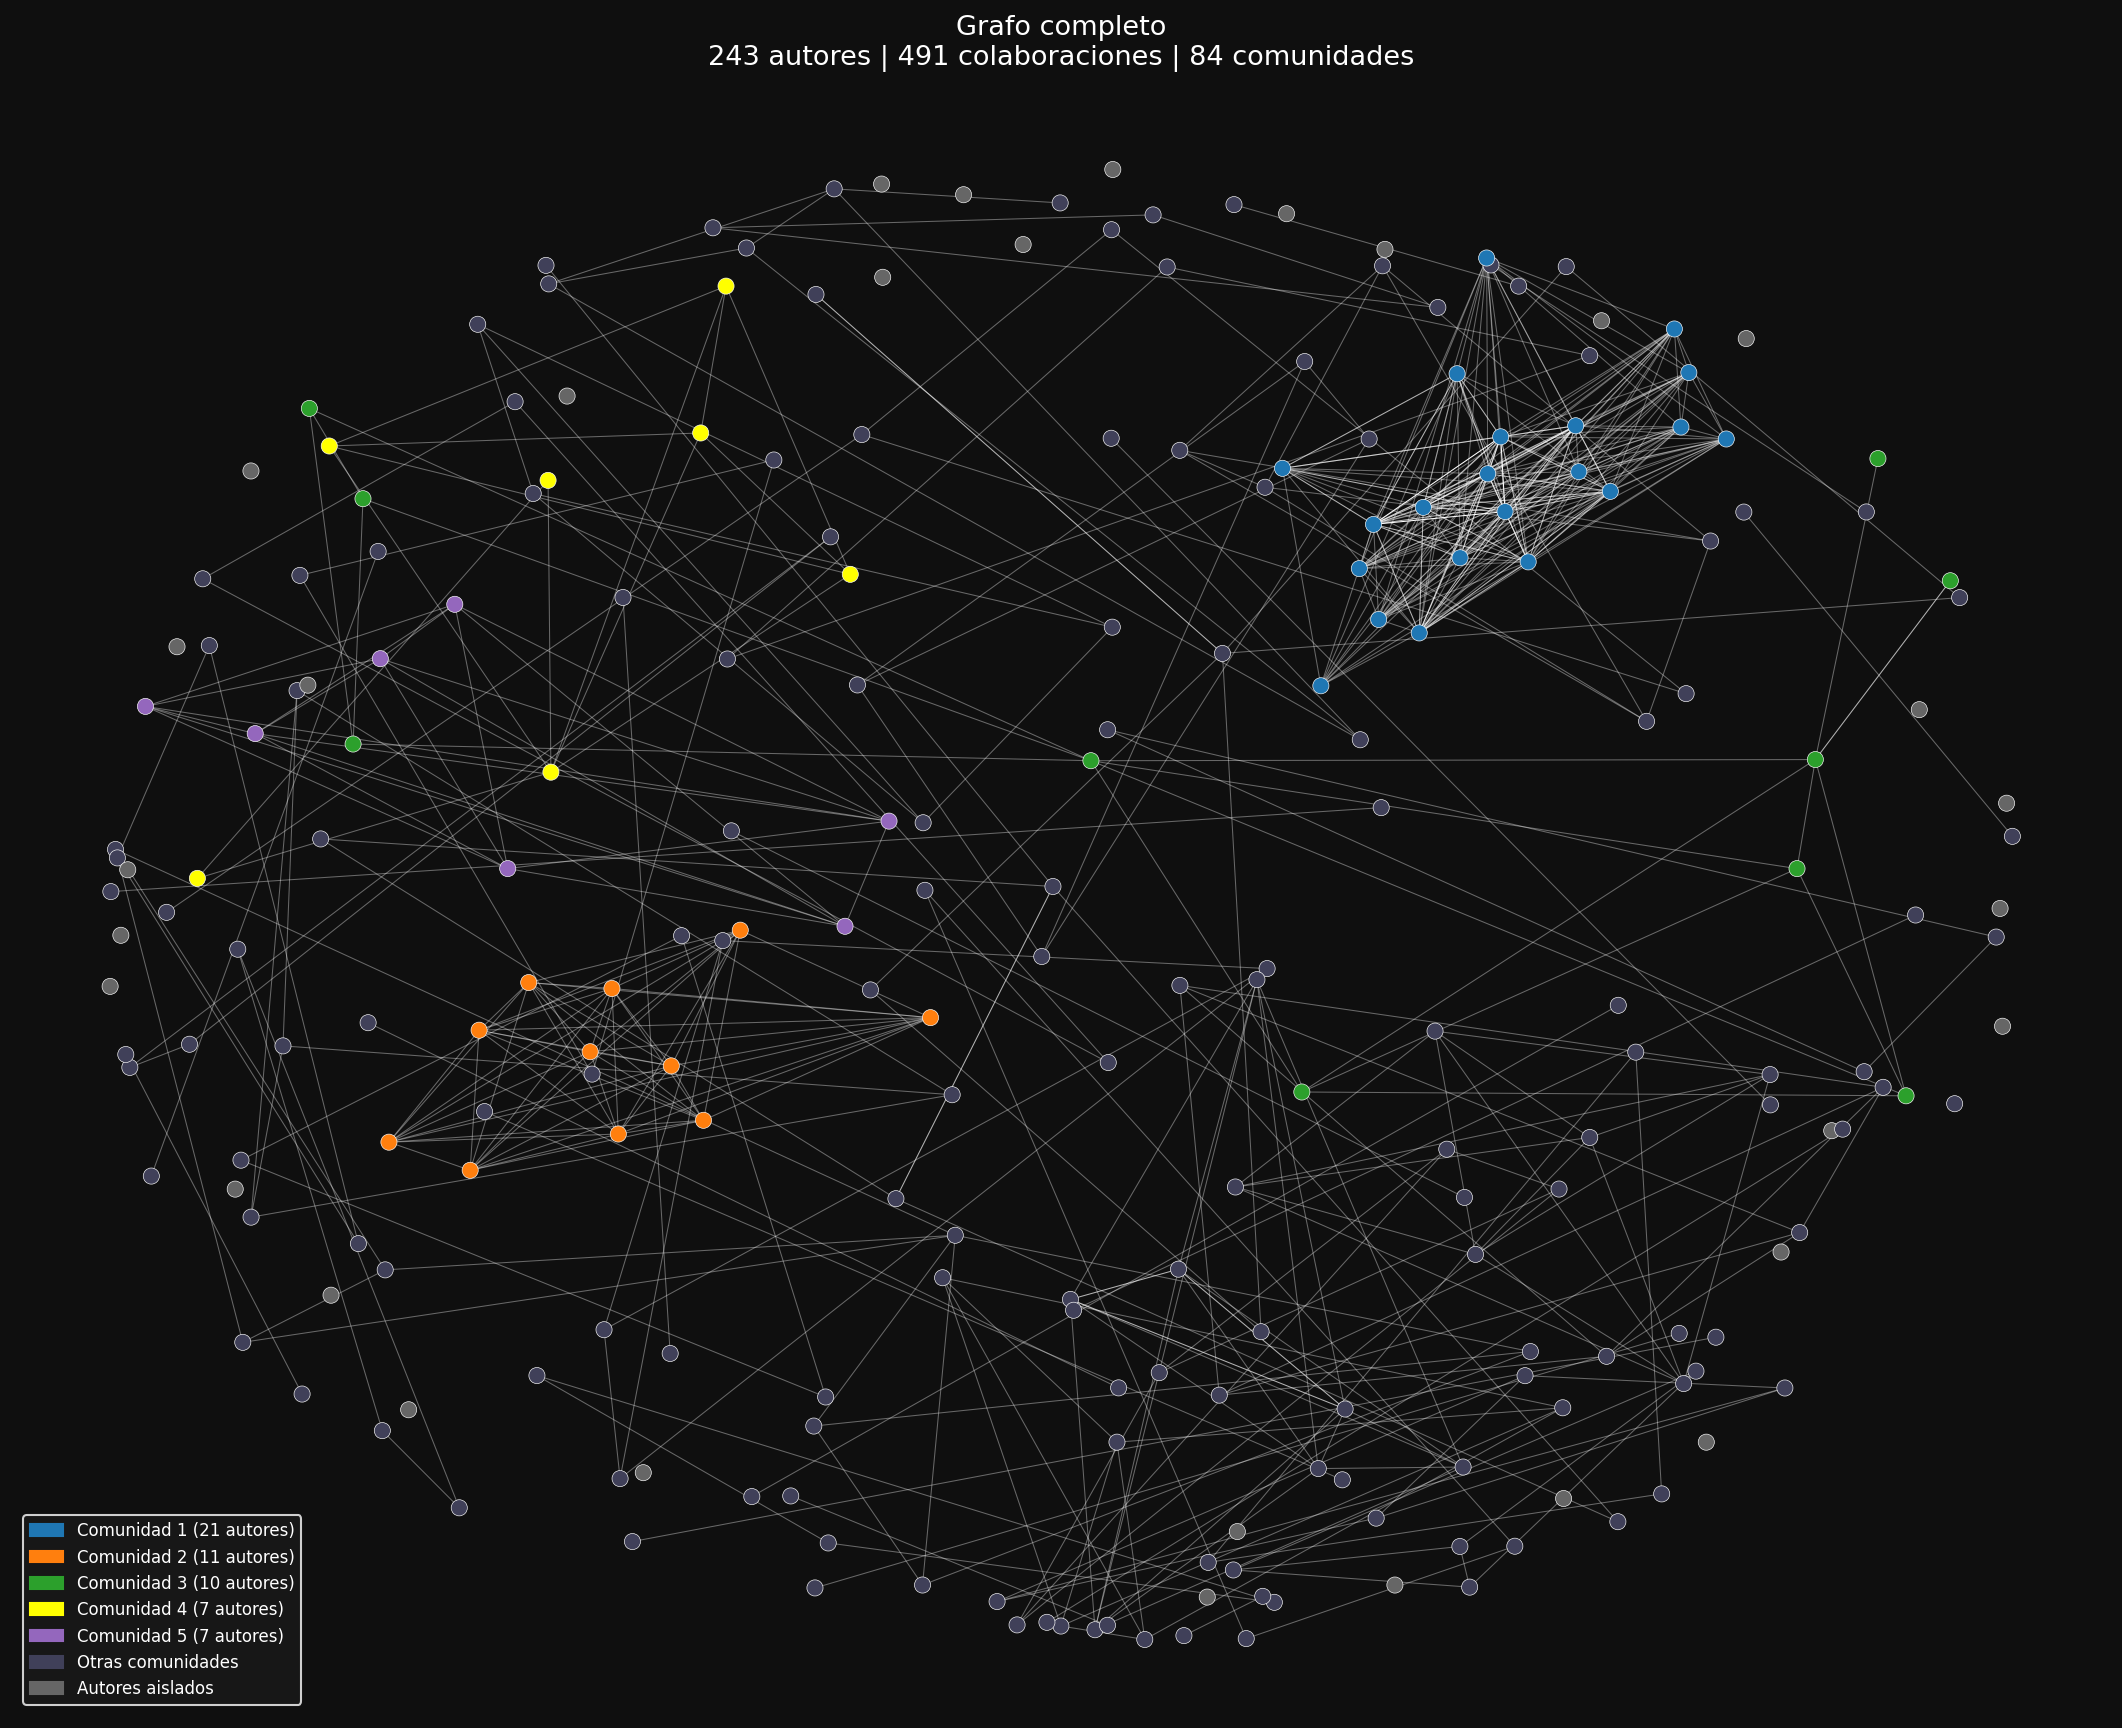

In [19]:
from IPython.display import Image, display
display(Image(filename='visualizaciones/grafo_completo.png'))

### Nodos importantes

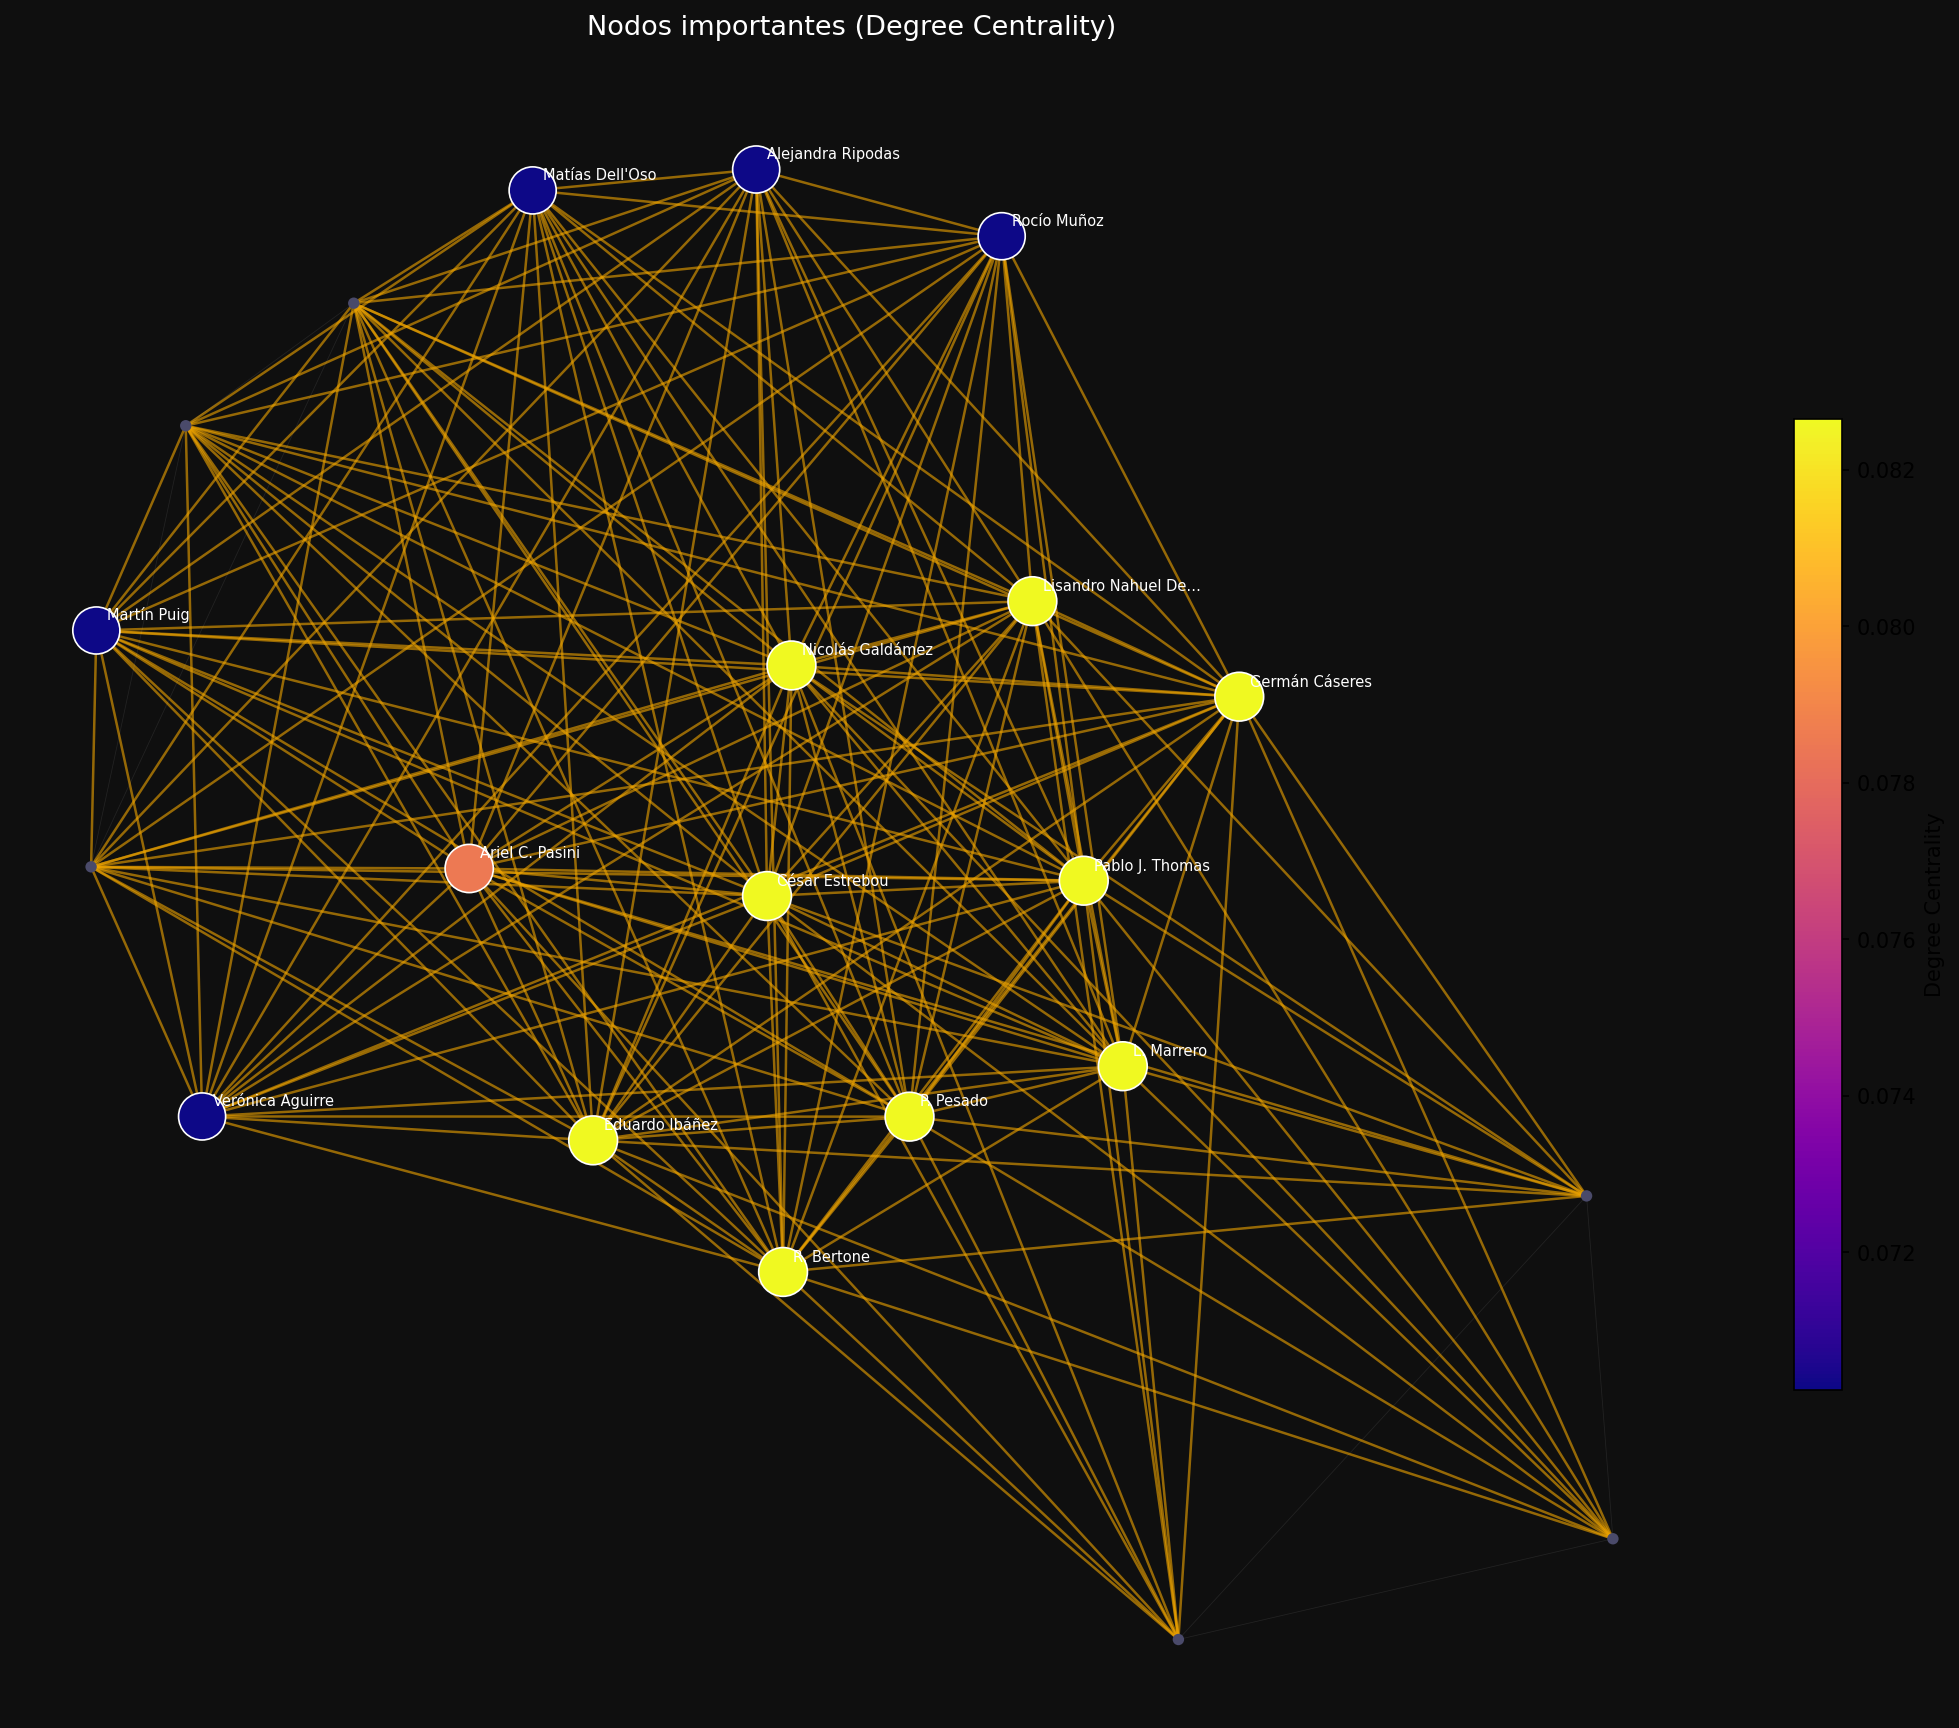

In [18]:
from IPython.display import Image, display
display(Image(filename='visualizaciones/nodos_importantes.png'))